In [2]:
X = np.array([5,2,2,1]).reshape(2,2)
X@X@X % 7

array([[1, 0],
       [0, 1]])

In [10]:
P = [1,2]
for _ in range(15):
    P.append(2*P[-1] + P[-2])
P = np.array(P)
P[::2] 

array([      1,       5,      29,     169,     985,    5741,   33461,
        195025, 1136689])

In [4]:
P % 7

array([1, 2, 5, 5, 1, 0, 1, 2, 5, 5, 1, 0, 1, 2, 5, 5, 1])

fib is period 8 mod 7
pell is period 3 mod 7

In [11]:
L = [1,1]
for _ in range(20):
    L.append(L[-1] + L[-2])
L = np.array(L)
L[::2] 

array([    1,     2,     5,    13,    34,    89,   233,   610,  1597,
        4181, 10946])

In [44]:
A = np.array([1,1,1,2],dtype=int).reshape(2,2)
B = np.array([2,1,1,1],dtype=int).reshape(2,2)
A,B

(array([[1, 1],
        [1, 2]]),
 array([[2, 1],
        [1, 1]]))

In [7]:
def m2a(A):
    C = np.copy(A)
    a,b,c,d = C.reshape(4)
    radius = np.sqrt((a+d)**2 - 4)/2/c
    center = (a-d)/2/c
    return center, radius

In [37]:
T = np.linspace(0,np.pi,20)
Z = np.exp(1J*T)

In [70]:
import mpmath

from mpmath import mp, sqrt, matrix

# Set precision to 50 decimal places
mp.dps = 50

def get_quantity(M):
    a, b, c, d = M[0,0], M[0,1], M[1,0], M[1,1]
    
    # Your specific formulas
    # r = sqrt((a+d)^2 - 4) / (2c)
    # x = (a-d) / (2c)
    r = sqrt((a+d)**2 - 4) / (2*c)
    x = (a-d) / (2*c)
    
    # The quantity: (sqrt(r^2 - 0.25) + x - 0.5) * b
    # Note: if r^2 < 0.25, this will become complex
    inner_sq = r**2 - mp.mpf('0.25')
    term1 = sqrt(inner_sq)
    
    return (term1 + x - mp.mpf('0.5')) * b

# Initialize matrices in mpmath
A = matrix([[1, 1], [1, 2]])
B = matrix([[2, 1], [1, 1]])
C = B

print(f"{'Iter':<5} | {'Quantity Value':<45}")
print("-" * 60)

for i in range(25):
    q = get_quantity(C)
    print(f"{i:<5} | {q}")
    C = A * C * A

Iter  | Quantity Value                               
------------------------------------------------------------
0     | 1.0
1     | 0.5574385243020006523441099976360016279269663198838
2     | 0.50824101193101486671008536948662687099406547921728
3     | 0.50119999769600884731753290030304030284854657295829
4     | 0.50017502916437918124077609164554901349541360749727
5     | 0.50002553539203118531046997643063029422345444275412
6     | 0.5000037255418178961137043465018173368716668700194
7     | 0.50000054354876465839014969364746441703308493879278
8     | 0.50000007930268619345453720633157959585488848306165
9     | 0.50000001157010577776372017672414501906683719398056
10    | 0.5000000016880556788105039520083610370893014145399
11    | 0.50000000024628400430481715718698058872970776356991
12    | 0.50000000003593235197021146927082973515438913254534
13    | 0.50000000000524245950043522285404832458476974159118
14    | 0.5000000000007648645331282467781127883438180004375
15    | 0.5000000000001

$ (2cx)^2 + c^2  = (a+d)^2 - 4$

In [27]:
#0.3819660559018776
c, r = m2a(B)
x = c-r + 2
x

np.float64(0.3819660112501051)

In [32]:
# Initial Matrices (using your int definitions)
A = np.array([0,-1,1,3],dtype=int).reshape(2,2)
B = np.array([1,1,1,2],dtype=int).reshape(2,2)

# Similarity transformation to the generator AA
C = B
V = []
for _ in range(16):

    # defect from 1/2 is 2/c
    c, r = m2a(C)
    print((c + r- x)*C[0,1]**2)
    #print((C[0,0] + C[1,1])//3)
    #print(C)
    C = C@A
    
V = np.array(V)

0.2360679774997898
0.1289902044919602
0.11602158704363541
0.11419132268804422
0.11392561642524957
0.11388687865071323
0.1138812274824208
0.11388040298407898
0.1138802824542382
0.11388026601565038
0.11388028799309868
0.11388051295763768
0.11388109804014168
0.11388288721933115
0.11390822530000566
0.11389124806852347


In [16]:
V[-1]/V[-2]

np.float64(6.854101966251898)

---

# recurrences, recurrences

In [288]:
M = np.zeros((3,3), dtype=int)
M[2] = [1,-8,8]
M[:2,1:] = np.identity(2)
M

array([[ 0,  1,  0],
       [ 0,  0,  1],
       [ 1, -8,  8]])

In [287]:
M @ V[2:5] - V[3:6]
(M - np.identity(3)) @ (1,1,1)

array([0., 0., 0.])

In [251]:
np.linalg.eig(M), (1/-0.02105857) * -0.57735027

(EigResult(eigenvalues=array([6.85410197, 0.14589803, 1.        ]), eigenvectors=array([[-0.02105857, -0.9893044 , -0.57735027],
        [-0.14433757, -0.14433757, -0.57735027],
        [-0.9893044 , -0.02105857, -0.57735027]])),
 27.416404342745025)

In [245]:
np.linalg.inv(M) # symmetric char poly

array([[ 8., -8.,  1.],
       [ 1.,  0.,  0.],
       [ 0.,  1.,  0.]])

In [244]:
M@M@M - 8*M@M  + 8*M  - np.identity(3)

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [198]:
V[:].reshape(4,4) @[1,-8,8,-1], np.linalg.det(V[:].reshape(4,4).astype(float))

(array([0, 0, 0, 0]), np.float64(-703908.3515609254))

(array([[ 0, -1],
        [ 1,  3]]),
 array([[1, 1],
        [1, 2]]))

[[1 1]
 [1 2]]
[[1 2]
 [2 5]]
[[ 2  5]
 [ 5 13]]
[[ 5 13]
 [13 34]]
[[13 34]
 [34 89]]
[[ 34  89]
 [ 89 233]]


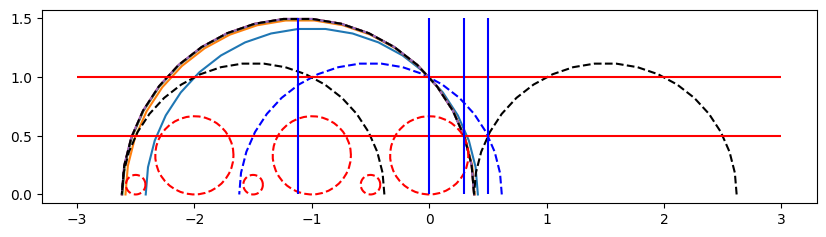

In [93]:
A = np.array([0,-1,1,3],dtype=int).reshape(2,2)
B = np.array([1,1,1,2],dtype=int).reshape(2,2)

fig, axes = plt.subplots( figsize=(10,10))
axes.set_aspect( "equal")

T = np.linspace(0,np.pi,20)
Z = np.exp(1J*T)
T = np.linspace(0,2*np.pi,40)
ZZ = np.exp(1J*T)

C = B
for _ in range(6):
    print(C)
    c,r = m2a(C)
    W = r*Z + c
    if _  >  0:
        axes.plot(W.real, W.imag)
    else:
        axes.plot(W.real, W.imag,'b',linestyle="dashed")
    
    C = C@A
    
c,r = m2a(A)
W = r*Z + c
axes.plot(W.real, W.imag,'k',linestyle="dashed")
W = W + 3
axes.plot(W.real, W.imag,'k',linestyle="dashed")
W = 3/2*Z - np.sqrt(5)/2
axes.plot(W.real, W.imag,'k',linestyle="dashed")

W = 1/3*ZZ + 1/3*1J 
axes.plot(W.real, W.imag,'r',linestyle="dashed")
W = W - 1
axes.plot(W.real, W.imag,'r',linestyle="dashed")
W = W - 1
axes.plot(W.real, W.imag,'r',linestyle="dashed")
W = 1/12*ZZ + 1/12*1J  - 1/2
axes.plot(W.real, W.imag,'r',linestyle="dashed")
W = W - 1
axes.plot(W.real, W.imag,'r',linestyle="dashed")
W = W - 1
axes.plot(W.real, W.imag,'r',linestyle="dashed")

plt.hlines([1,.5],-3,3,'r');
plt.vlines([0,.5,- np.sqrt(5)/2, np.sqrt(2) - np.sqrt(5)/2],0,3/2,'b');


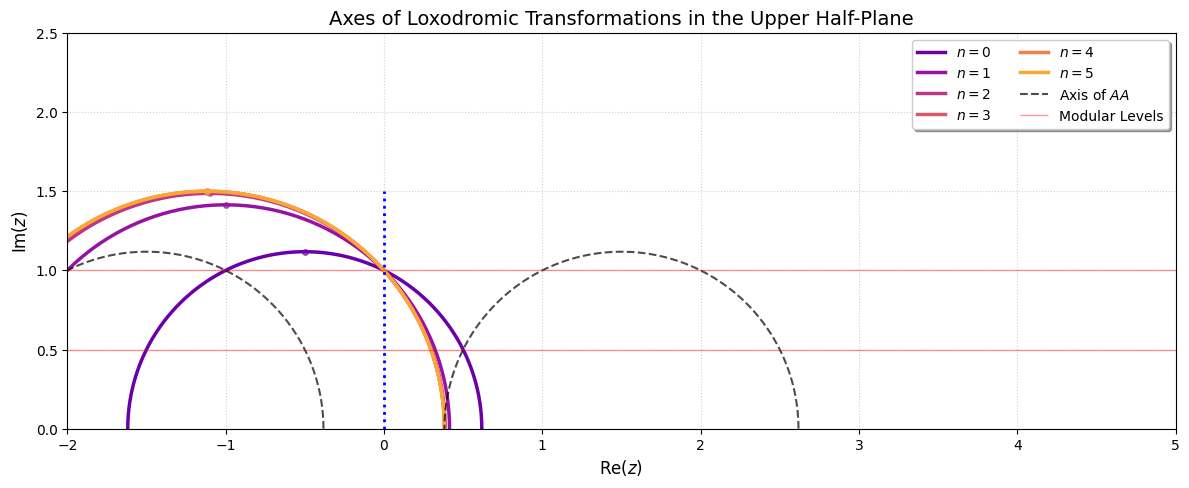

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def m2a(A):
    """Calculates center and radius of the axis of a loxodromic transformation."""
    a, b, c, d = A.astype(float).ravel()
    # The term (a+d)**2 - 4 is the discriminant (trace^2 - 4)
    # This is exactly the E_n structure we analyzed earlier!
    radius = np.sqrt((a + d)**2 - 4) / (2 * c)
    center = (a - d) / (2 * c)
    return center, radius

# Initial Matrices (using your int definitions)
A = np.array([[1, 1], [1, 2]], dtype=int)
B = np.array([[2, 1], [1, 1]], dtype=int)
Q = np.array([[1, 1], [0, 1]], dtype=int)
q = np.array([[1, -1], [0, 1]], dtype=int)

# Similarity transformation to the generator AA
AA = q @ A @ Q
C_iter = q @ B @ Q

# Visualization Setup
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_aspect("equal")
ax.grid(True, linestyle=':', alpha=0.6)

# High-resolution arc
T = np.linspace(0, np.pi, 250)
Z = np.exp(1J * T)

# Plotting the sequence of loxodromic axes
# Using a colormap to show the evolution through n
colors = plt.cm.plasma(np.linspace(0.2, 0.8, 6))

for i in range(6):
    c, r = m2a(C_iter)
    W = r * Z + c
    
    # Draw the axis
    ax.plot(W.real, W.imag, color=colors[i], lw=2.5, label=f'$n={i}$')
    # Add a marker at the apex of the axis
    ax.plot(c, r, 'o', color=colors[i], markersize=4, alpha=0.6)
    
    C_iter = C_iter @ AA

# Plot the generator AA axis (Dashed)
c_gen, r_gen = m2a(AA)
W_gen = r_gen * Z + c_gen
ax.plot(W_gen.real, W_gen.imag, 'k--', lw=1.5, alpha=0.7, label='Axis of $AA$')
ax.plot(W_gen.real + 3, W_gen.imag, 'k--', lw=1.5, alpha=0.7)

# Reference Lines
ax.hlines([1, 0.5], -3, 6, colors='red', alpha=0.4, lw=1, label='Modular Levels')
ax.vlines(0, 0, 1.5, colors='blue', linestyles=':', lw=2)

# Aesthetics
ax.set_title("Axes of Loxodromic Transformations in the Upper Half-Plane", fontsize=14)
ax.set_xlabel("$\\text{Re}(z)$", fontsize=12)
ax.set_ylabel("$\\text{Im}(z)$", fontsize=12)
ax.legend(loc='upper right', frameon=True, shadow=True, ncol=2)
ax.set_xlim(-2, 5)
ax.set_ylim(0, 2.5)

plt.tight_layout()
plt.show()



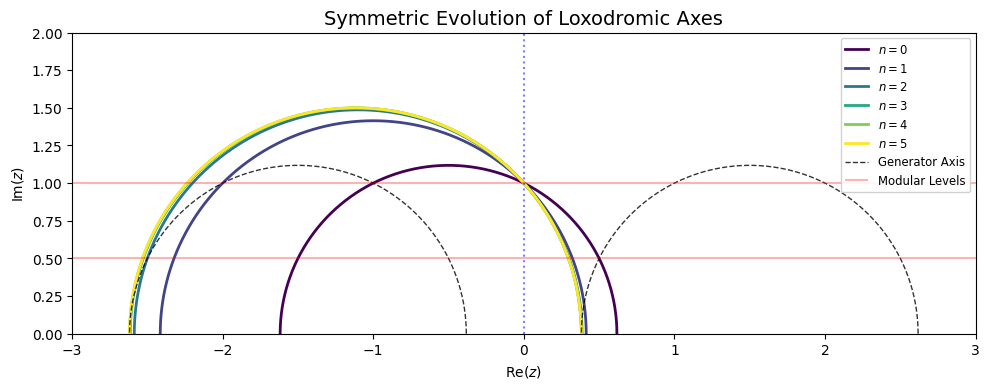

In [155]:

import numpy as np
import matplotlib.pyplot as plt

def m2a(A):
    """Calculates center and radius of the axis of a loxodromic transformation."""
    # Using float conversion to ensure precision in sqrt and division
    a, b, c, d = A.astype(float).ravel()
    # Discriminant delta = trace^2 - 4
    delta = (a + d)**2 - 4
    # Ensure we are handling a loxodromic case (delta > 0)
    radius = np.sqrt(delta) / (2 * c)
    center = (a - d) / (2 * c)
    return center, radius

# Matrices from your specification
A = np.array([[1, 1], [1, 2]], dtype=int)
B = np.array([[2, 1], [1, 1]], dtype=int)
Q = np.array([[1, 1], [0, 1]], dtype=int)
q = np.array([[1, -1], [0, 1]], dtype=int)

# Similarity transformations
AA = q @ A @ Q
C_iter = q @ B @ Q

# Plotting Setup
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_aspect("equal")

# Arc resolution
T = np.linspace(0, np.pi, 500)
Z = np.exp(1J * T)

# Sequence colors
colors = plt.cm.viridis(np.linspace(0, 1, 6))

for i in range(6):
    c, r = m2a(C_iter)
    W = r * Z + c
    ax.plot(W.real, W.imag, color=colors[i], lw=2, label=f'$n={i}$')
    C_iter = C_iter @ AA

# Plotting generator axes (Dashed)
c_gen, r_gen = m2a(AA)
W_gen = r_gen * Z + c_gen
ax.plot(W_gen.real, W_gen.imag, 'k--', 
        lw=1, alpha=0.8, label='Generator Axis')
# Secondary generator axis at +3
ax.plot(W_gen.real + 3, W_gen.imag, 'k--', 
        lw=1, alpha=0.8)

# Center-focused formatting
plt.hlines([1, 0.5], -5, 5, colors='r', 
           alpha=0.3, label='Modular Levels')
plt.vlines(0, 0, 2, colors='b', 
           linestyle=':', alpha=0.5)

# Centering the view on 0
ax.set_xlim(-3, 3)
ax.set_ylim(0, 2)

ax.set_title("Symmetric Evolution of Loxodromic Axes", fontsize=14)
ax.set_xlabel("$\\text{Re}(z)$")
ax.set_ylabel("$\\text{Im}(z)$")
ax.legend(loc='upper right', fontsize='small', framealpha=0.9)

plt.tight_layout()
plt.show()


In [59]:
np.array([5,2,8,3]).reshape(2,2)

array([[5, 2],
       [8, 3]])

In [181]:
V

array([        4,        28,       196,      1348,      9244,     63364,
          434308,   2976796,  20403268, 139846084])

In [185]:
np.linalg.det(V[:9].reshape(3,3))

np.float64(-7077887.999999307)

In [188]:
len(V)

10

n   | Center     | Apex Height (r)
-----------------------------------
0   | -0.5000    | 1.1180         
1   | -1.0000    | 1.4142         
2   | -1.1000    | 1.4866         
3   | -1.1154    | 1.4980         
4   | -1.1176    | 1.4997         
5   | -1.1180    | 1.5000         


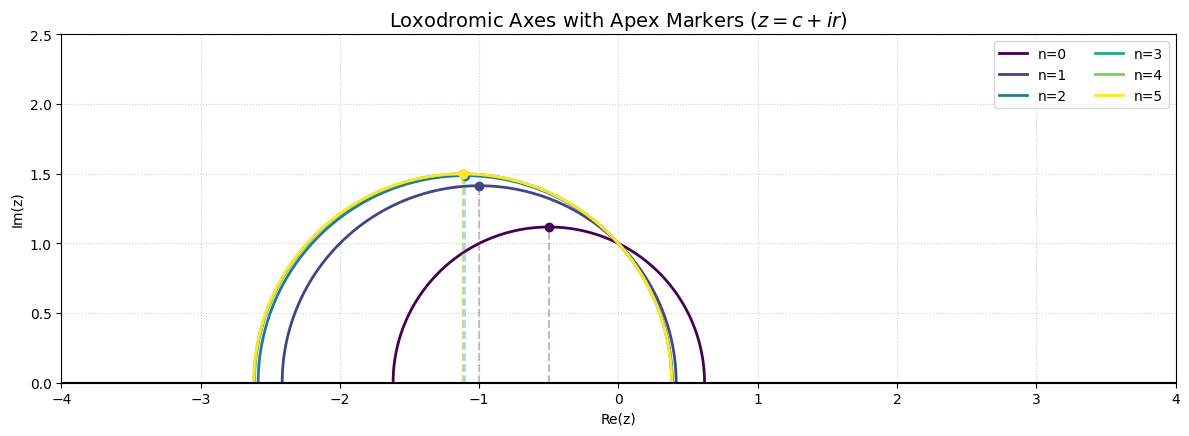

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def m2a(A):
    """Calculates center and radius of the axis of a loxodromic transformation."""
    a, b, c, d = A.astype(float).ravel()
    # Discriminant delta = trace^2 - 4
    delta = (a + d)**2 - 4
    radius = np.sqrt(delta) / (2 * c)
    center = (a - d) / (2 * c)
    return center, radius

# Matrices
A = np.array([[1, 1], [1, 2]], dtype=int)
B = np.array([[2, 1], [1, 1]], dtype=int)
Q = np.array([[1, 1], [0, 1]], dtype=int)
q = np.array([[1, -1], [0, 1]], dtype=int)

AA = q @ A @ Q
C_iter = q @ B @ Q

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_aspect("equal")

T = np.linspace(0, np.pi, 500)
Z = np.exp(1J * T)
colors = plt.cm.viridis(np.linspace(0, 1, 6))

print(f"{'n':<3} | {'Center':<10} | {'Apex Height (r)':<15}")
print("-" * 35)

for i in range(6):
    c, r = m2a(C_iter)
    W = r * Z + c
    
    # Plot Arc
    ax.plot(W.real, W.imag, color=colors[i], lw=2, label=f'n={i}')
    
    # Mark Apex
    ax.plot(c, r, 'o', color=colors[i], markersize=6)
    ax.vlines(c, 0, r, color=colors[i], linestyle='--', alpha=0.3)
    
    # Print values for verification
    print(f"{i:<3} | {c:<10.4f} | {r:<15.4f}")
    
    C_iter = C_iter @ AA

# Formatting
ax.axhline(0, color='black', lw=1.5) # The Real Axis
ax.set_xlim(-4, 4)
ax.set_ylim(0, 2.5)
ax.set_title("Loxodromic Axes with Apex Markers ($z = c + ir$)", fontsize=14)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.legend(loc='upper right', ncol=2)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()